# Benchmark: `polyhedral_gravity.torch` vs C++ `evaluate`

Three experiments:

1. **Vary Q** (computation points) — fixed body (cube, F=12). Shows where PyTorch's batch advantage takes over from the C++ per-point loop.
2. **Vary F** (faces) — fixed Q=200. Shows per-face scaling and the constant-factor difference between the two implementations.
3. **Gradient overhead** — forward vs forward+backward on CPU. Quantifies the cost of one autodiff training step.

All timings are **median** over 7 runs after 3 warm-up calls.
The C++ interface uses `PolyhedronIntegrity.DISABLE` (no mesh validation) to measure compute time only.

### Key takeaway
- The **C++ interface is faster for pure forward evaluation** in almost all regimes because it avoids tensor allocation and Python overhead.
- The **PyTorch GPU interface breaks even** (and eventually wins) at large Q where the parallel GPU throughput dominates.
- Use `polyhedral_gravity.torch` when you need **gradients** — the C++ interface cannot provide them at all.

#### Benchmark hardware
Intel Xeon w7-3565X (64 logical cores) · NVIDIA RTX 5000 Ada Generation (32 GB VRAM, Ada Lovelace sm_89).

C++ uses all 64 threads via TBB; PyTorch CPU set to use 64 threads

In [1]:
import time
import numpy as np
import torch
import matplotlib.pyplot as plt

from polyhedral_gravity import Polyhedron, evaluate, NormalOrientation, PolyhedronIntegrity
from polyhedral_gravity.torch import evaluate as torch_evaluate

CUDA = torch.cuda.is_available()
GPU_NAME = torch.cuda.get_device_name(0) if CUDA else None

torch.set_num_threads(64)
print(f"torch {torch.__version__}  |  CPU threads: {torch.get_num_threads()}  |  CUDA: {CUDA}",
      f"({GPU_NAME})" if CUDA else "")

RNG = np.random.default_rng(42)
N_WARMUP, N_REPEAT = 3, 7

torch 2.12.0+cu130  |  CPU threads: 64  |  CUDA: True (NVIDIA RTX 5000 Ada Generation)


## Helper utilities

In [2]:
# ── Mesh generation ─────────────────────────────────────────────────────────

_PHI = (1.0 + np.sqrt(5.0)) / 2.0
_BASE_VERTS = np.array([
    [-1,  _PHI,  0], [ 1,  _PHI,  0], [-1, -_PHI,  0], [ 1, -_PHI,  0],
    [ 0, -1,  _PHI], [ 0,  1,  _PHI], [ 0, -1, -_PHI], [ 0,  1, -_PHI],
    [ _PHI,  0, -1], [ _PHI,  0,  1], [-_PHI,  0, -1], [-_PHI,  0,  1],
], dtype=np.float64)
_BASE_FACES = np.array([
    [ 0, 11,  5], [ 0,  5,  1], [ 0,  1,  7], [ 0,  7, 10], [ 0, 10, 11],
    [ 1,  5,  9], [ 5, 11,  4], [11, 10,  2], [10,  7,  6], [ 7,  1,  8],
    [ 3,  9,  4], [ 3,  4,  2], [ 3,  2,  6], [ 3,  6,  8], [ 3,  8,  9],
    [ 4,  9,  5], [ 2,  4, 11], [ 6,  2, 10], [ 8,  6,  7], [ 9,  8,  1],
], dtype=np.int64)

def _subdivide(verts, faces):
    vlist = list(verts)
    new_faces, cache = [], {}
    def mid(i, j):
        key = (min(i, j), max(i, j))
        if key not in cache:
            m = (vlist[i] + vlist[j]) / 2.0
            cache[key] = len(vlist)
            vlist.append(m / np.linalg.norm(m))
        return cache[key]
    for a, b, c in faces:
        ab, bc, ca = mid(a, b), mid(b, c), mid(c, a)
        new_faces += [[a, ab, ca], [b, bc, ab], [c, ca, bc], [ab, bc, ca]]
    return np.array(vlist, dtype=np.float64), np.array(new_faces, dtype=np.int64)

def make_icosphere(level=0, radius=1.0):
    """Icosphere with 20·4^level faces."""
    verts = _BASE_VERTS / np.linalg.norm(_BASE_VERTS[0])
    faces = _BASE_FACES.copy()
    for _ in range(level):
        verts, faces = _subdivide(verts, faces)
    return verts * radius, faces

def make_unit_cube():
    verts = np.array([
        [-1,-1,-1],[1,-1,-1],[1,1,-1],[-1,1,-1],
        [-1,-1, 1],[1,-1, 1],[1,1, 1],[-1,1, 1],
    ], dtype=np.float64)
    faces = np.array([
        [1,3,2],[0,3,1],[0,1,5],[0,5,4],[0,7,3],[0,4,7],
        [1,2,6],[1,6,5],[2,3,6],[3,7,6],[4,5,6],[4,6,7],
    ], dtype=np.int64)
    return verts, faces

def sample_exterior_points(Q, radius, rng):
    pts = rng.standard_normal((Q, 3))
    pts /= np.linalg.norm(pts, axis=1, keepdims=True)
    return (pts * radius).astype(np.float64)


# ── Timing helpers ───────────────────────────────────────────────────────────

def _median(fn, n_warmup, n_repeat):
    for _ in range(n_warmup):
        fn()
    times = []
    for _ in range(n_repeat):
        t0 = time.perf_counter()
        fn()
        times.append(time.perf_counter() - t0)
    return float(np.median(times))

def _median_cuda(fn, n_warmup, n_repeat):
    for _ in range(n_warmup):
        fn(); torch.cuda.synchronize()
    times = []
    for _ in range(n_repeat):
        torch.cuda.synchronize()
        t0 = time.perf_counter()
        fn()
        torch.cuda.synchronize()
        times.append(time.perf_counter() - t0)
    return float(np.median(times))

def time_cpp(verts_np, faces_np, pts_np, n_warmup=N_WARMUP, n_repeat=N_REPEAT):
    poly = Polyhedron(
        (verts_np, faces_np), density=1.0,
        normal_orientation=NormalOrientation.OUTWARDS,
        integrity_check=PolyhedronIntegrity.DISABLE,
    )
    pts = pts_np.tolist()
    return _median(lambda: evaluate(poly, pts), n_warmup, n_repeat)

def time_torch_fwd(verts_np, faces_np, pts_np, device="cpu",
                   n_warmup=N_WARMUP, n_repeat=N_REPEAT):
    verts = torch.tensor(verts_np, dtype=torch.float64, device=device)
    faces = torch.tensor(faces_np, dtype=torch.long,    device=device)
    pts   = torch.tensor(pts_np,   dtype=torch.float64, device=device)
    def fn():
        with torch.no_grad():
            torch_evaluate(verts, faces, 1.0, pts)
    if torch.device(device).type == "cuda":
        return _median_cuda(fn, n_warmup, n_repeat)
    return _median(fn, n_warmup, n_repeat)

def time_torch_fwd_bwd(verts_np, faces_np, pts_np,
                       n_warmup=N_WARMUP, n_repeat=N_REPEAT):
    faces = torch.tensor(faces_np, dtype=torch.long)
    pts   = torch.tensor(pts_np,   dtype=torch.float64)
    def fn():
        verts = torch.tensor(verts_np, dtype=torch.float64, requires_grad=True)
        V, _, __ = torch_evaluate(verts, faces, 1.0, pts)
        V.sum().backward()
    return _median(fn, n_warmup, n_repeat)

## Experiment 1 — Vary Q, fixed body

Body: unit cube, F=12 faces.  
Both implementations are O(Q·F) in work. The C++ interface loops over points sequentially (with OpenMP threads); `polyhedral_gravity.torch` materialises a single `(Q, F, ...)` tensor and runs everything in one vectorised pass. The crossover shows where PyTorch's batch advantage outweighs its Python/tensor-allocation overhead.

In [3]:
cube_v, cube_f = make_unit_cube()
Q_VALUES = [1, 5, 20, 100, 500, 2000, 10_000, 50_000, 200_000, 1_000_000]

res_q = {"Q": [], "cpp": [], "torch_cpu": [], "torch_gpu": []}

for Q in Q_VALUES:
    pts = sample_exterior_points(Q, radius=10.0, rng=RNG)
    res_q["Q"].append(Q)
    res_q["cpp"].append(time_cpp(cube_v, cube_f, pts))
    res_q["torch_cpu"].append(time_torch_fwd(cube_v, cube_f, pts, "cpu"))
    if CUDA:
        res_q["torch_gpu"].append(time_torch_fwd(cube_v, cube_f, pts, "cuda"))
    print(f"Q={Q:6d}  C++={res_q['cpp'][-1]*1e3:7.3f}ms  "
          f"CPU={res_q['torch_cpu'][-1]*1e3:7.3f}ms"
          + (f"  GPU={res_q['torch_gpu'][-1]*1e3:7.3f}ms" if CUDA else ""))

Q=     1  C++=  0.004ms  CPU=  0.387ms  GPU=  0.845ms
Q=     5  C++=  0.014ms  CPU=  0.719ms  GPU=  1.061ms
Q=    20  C++=  0.028ms  CPU=  0.876ms  GPU=  0.972ms
Q=   100  C++=  0.056ms  CPU=  1.710ms  GPU=  0.892ms
Q=   500  C++=  0.263ms  CPU=  4.534ms  GPU=  0.835ms
Q=  2000  C++=  0.984ms  CPU= 12.342ms  GPU=  0.860ms
Q= 10000  C++=  4.928ms  CPU= 20.257ms  GPU=  1.095ms
Q= 50000  C++= 23.861ms  CPU= 89.791ms  GPU=  7.624ms
Q=200000  C++=129.532ms  CPU=399.054ms  GPU= 42.983ms
Q=1000000  C++=733.749ms  CPU=1704.293ms  GPU=226.536ms


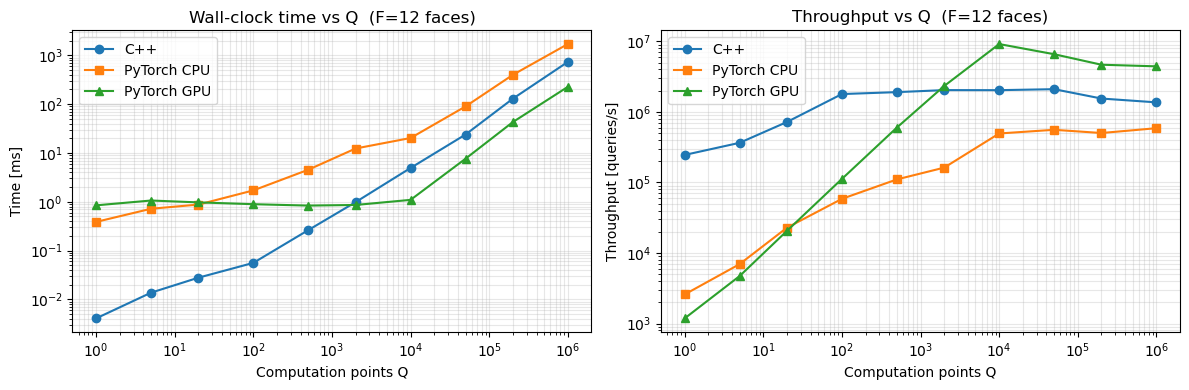

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
Q = np.array(res_q["Q"])

ax1.loglog(Q, np.array(res_q["cpp"])       * 1e3, "o-", label="C++")
ax1.loglog(Q, np.array(res_q["torch_cpu"]) * 1e3, "s-", label="PyTorch CPU")
if CUDA:
    ax1.loglog(Q, np.array(res_q["torch_gpu"]) * 1e3, "^-", label="PyTorch GPU")
ax1.set_xlabel("Computation points Q"); ax1.set_ylabel("Time [ms]")
ax1.set_title("Wall-clock time vs Q  (F=12 faces)")
ax1.legend(); ax1.grid(True, which="both", alpha=0.3)

ax2.loglog(Q, Q / np.array(res_q["cpp"]),       "o-", label="C++")
ax2.loglog(Q, Q / np.array(res_q["torch_cpu"]), "s-", label="PyTorch CPU")
if CUDA:
    ax2.loglog(Q, Q / np.array(res_q["torch_gpu"]), "^-", label="PyTorch GPU")
ax2.set_xlabel("Computation points Q"); ax2.set_ylabel("Throughput [queries/s]")
ax2.set_title("Throughput vs Q  (F=12 faces)")
ax2.legend(); ax2.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

## Experiment 2 — Vary F, fixed Q

Body: icospheres at subdivision levels 0–4 (F = 20, 80, 320, 1280, 5120 faces).  
Q=200 points on a sphere of radius 10. Both implementations are O(F) per query, but with different constants.

In [5]:
Q_FIXED = 200
pts_fixed = sample_exterior_points(Q_FIXED, radius=10.0, rng=RNG)
meshes = [(20 * 4**lvl, *make_icosphere(lvl)) for lvl in range(7)]

res_f = {"F": [], "cpp": [], "torch_cpu": [], "torch_gpu": []}

for F, v, f in meshes:
    res_f["F"].append(F)
    res_f["cpp"].append(time_cpp(v, f, pts_fixed))
    res_f["torch_cpu"].append(time_torch_fwd(v, f, pts_fixed, "cpu"))
    if CUDA:
        res_f["torch_gpu"].append(time_torch_fwd(v, f, pts_fixed, "cuda"))
    print(f"F={F:5d}  C++={res_f['cpp'][-1]*1e3:7.3f}ms  "
          f"CPU={res_f['torch_cpu'][-1]*1e3:7.3f}ms"
          + (f"  GPU={res_f['torch_gpu'][-1]*1e3:7.3f}ms" if CUDA else ""))

F=   20  C++=  0.113ms  CPU=  3.101ms  GPU=  0.977ms
F=   80  C++=  0.202ms  CPU=  6.258ms  GPU=  0.904ms
F=  320  C++=  0.584ms  CPU= 10.612ms  GPU=  0.899ms
F= 1280  C++=  1.954ms  CPU= 45.494ms  GPU=  2.434ms
F= 5120  C++=  7.351ms  CPU= 86.574ms  GPU= 15.342ms
F=20480  C++= 27.909ms  CPU=721.260ms  GPU= 75.695ms
F=81920  C++=102.374ms  CPU=2508.705ms  GPU=310.073ms


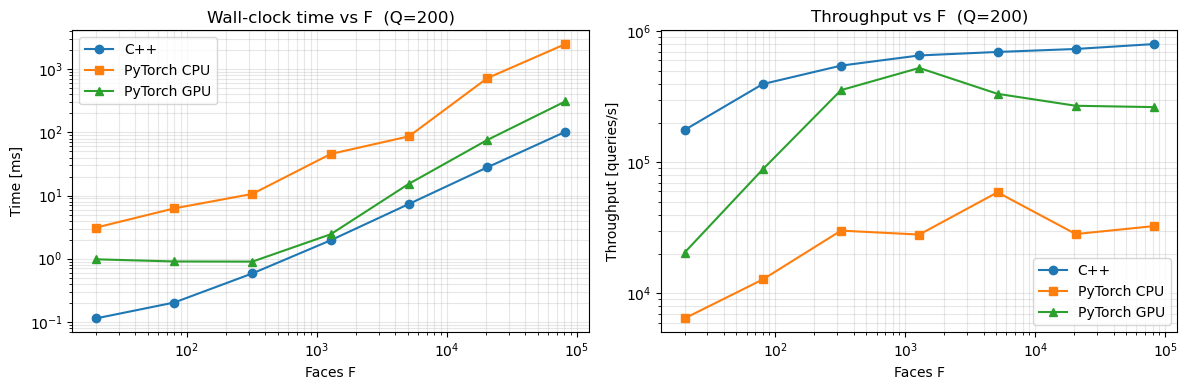

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
F_arr = np.array(res_f["F"])
cpp_ms = np.array(res_f["cpp"]) * 1e3

ax1.loglog(F_arr, cpp_ms,                                  "o-", label="C++")
ax1.loglog(F_arr, np.array(res_f["torch_cpu"]) * 1e3,     "s-", label="PyTorch CPU")
if CUDA:
    ax1.loglog(F_arr, np.array(res_f["torch_gpu"]) * 1e3, "^-", label="PyTorch GPU")
ax1.set_xlabel("Faces F"); ax1.set_ylabel("Time [ms]")
ax1.set_title(f"Wall-clock time vs F  (Q={Q_FIXED})")
ax1.legend(); ax1.grid(True, which="both", alpha=0.3)

# ax2.loglog(Q, Q / np.array(res_q["cpp"]),       "o-", label="C++")
# ax2.loglog(Q, Q / np.array(res_q["torch_cpu"]), "s-", label="PyTorch CPU")
# if CUDA:
#     ax2.loglog(Q, Q / np.array(res_q["torch_gpu"]), "^-", label="PyTorch GPU")
# ax2.set_xlabel("Computation points Q"); ax2.set_ylabel("Throughput [queries/s]")
# ax2.set_title("Throughput vs Q  (F=12 faces)")
# ax2.legend(); ax2.grid(True, which="both", alpha=0.3)

ax2.loglog(F_arr, F_arr / (np.array(res_f["cpp"])), "o-", label="C++")
ax2.loglog(F_arr, F_arr / (np.array(res_f["torch_cpu"])), "s-", label="PyTorch CPU")
if CUDA:
    ax2.loglog(F_arr, F_arr / (np.array(res_f["torch_gpu"])), "^-", label="PyTorch GPU")
ax2.set_xlabel("Faces F")
ax2.set_ylabel("Throughput [queries/s]")
ax2.set_title(f"Throughput vs F  (Q={Q_FIXED})")
ax2.legend()
ax2.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

## Experiment 3 — Gradient overhead (PyTorch CPU)

The C++ interface cannot compute gradients at all. This experiment quantifies the **backward-pass overhead** relative to the forward pass, to inform the cost of one gradient-descent training step.

Gradient is taken with respect to all vertex positions; body is the unit cube (F=12).

In [7]:
Q_GRAD = [1, 5, 20, 100, 500, 2000]

res_g = {"Q": [], "fwd": [], "fwd_bwd": []}

for Q in Q_GRAD:
    pts = sample_exterior_points(Q, radius=10.0, rng=RNG)
    res_g["Q"].append(Q)
    res_g["fwd"].append(time_torch_fwd(cube_v, cube_f, pts, "cpu"))
    res_g["fwd_bwd"].append(time_torch_fwd_bwd(cube_v, cube_f, pts))
    ratio = res_g["fwd_bwd"][-1] / res_g["fwd"][-1]
    print(f"Q={Q:5d}  fwd={res_g['fwd'][-1]*1e3:7.3f}ms  "
          f"fwd+bwd={res_g['fwd_bwd'][-1]*1e3:7.3f}ms  ratio={ratio:.2f}x")

Q=    1  fwd=  0.397ms  fwd+bwd=  1.160ms  ratio=2.92x
Q=    5  fwd=  0.703ms  fwd+bwd=  2.089ms  ratio=2.97x
Q=   20  fwd=  0.890ms  fwd+bwd=  2.549ms  ratio=2.86x
Q=  100  fwd=  1.706ms  fwd+bwd=  4.560ms  ratio=2.67x
Q=  500  fwd=  4.226ms  fwd+bwd= 11.335ms  ratio=2.68x
Q= 2000  fwd=  6.958ms  fwd+bwd= 19.844ms  ratio=2.85x


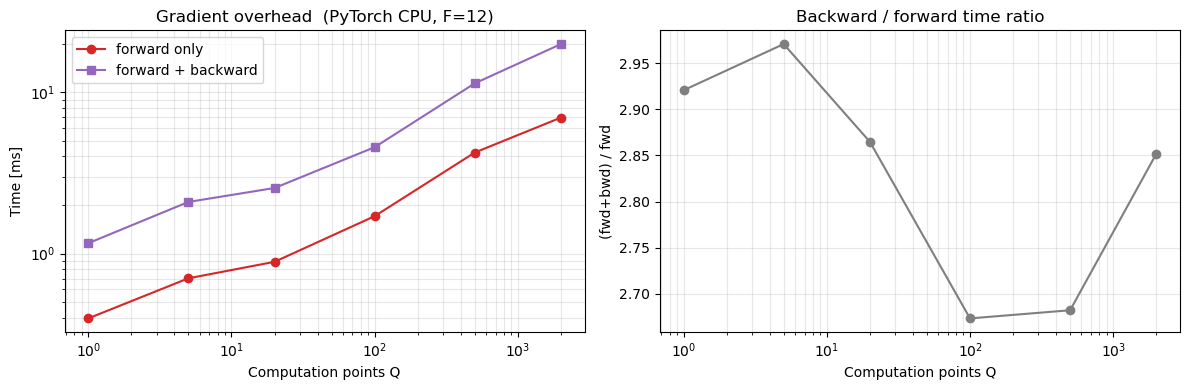

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
Q   = np.array(res_g["Q"])
fwd     = np.array(res_g["fwd"])     * 1e3
fwd_bwd = np.array(res_g["fwd_bwd"]) * 1e3

ax1.loglog(Q, fwd,     "o-", label="forward only", color='C3')
ax1.loglog(Q, fwd_bwd, "s-", label="forward + backward", color='C4')
ax1.set_xlabel("Computation points Q"); ax1.set_ylabel("Time [ms]")
ax1.set_title("Gradient overhead  (PyTorch CPU, F=12)")
ax1.legend(); ax1.grid(True, which="both", alpha=0.3)

ax2.semilogx(Q, fwd_bwd / fwd, "o-", color="C7")
ax2.set_xlabel("Computation points Q"); ax2.set_ylabel("(fwd+bwd) / fwd")
ax2.set_title("Backward / forward time ratio")
ax2.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

Speed-up table: C++ time / PyTorch time at selected (Q, F) operating points.  
Values > 1 mean PyTorch is faster; values < 1 mean C++ is faster.

In [9]:
import platform

def _cpu_name():
    try:
        with open("/proc/cpuinfo") as f:
            for line in f:
                if line.startswith("model name"):
                    return line.split(":", 1)[1].strip()
    except OSError:
        pass
    return platform.processor() or platform.machine()

print(f"Hardware:  CPU: {_cpu_name()}")
if CUDA:
    props = torch.cuda.get_device_properties(0)
    print(f"           GPU: {GPU_NAME}  ({props.total_memory // 2**20} MB VRAM, "
          f"sm_{props.major}{props.minor}, {props.multi_processor_count} SMs)")
print()

header = f"{'':>10}  {'C++ [ms]':>10}  {'CPU [ms]':>10}  {'CPU speedup':>12}"
if CUDA:
    header += f"  {'GPU [ms]':>10}  {'GPU speedup':>12}"
print(header)
print("-" * (58 + (28 if CUDA else 0)))

print("  --- Vary Q (F=12 faces) ---")
for i, Q in enumerate(res_q["Q"]):
    cpp = res_q["cpp"][i] * 1e3
    cpu = res_q["torch_cpu"][i] * 1e3
    row = f"Q={Q:>7d}  {cpp:>10.3f}  {cpu:>10.3f}  {cpp/cpu:>11.2f}x"
    if CUDA:
        gpu = res_q["torch_gpu"][i] * 1e3
        row += f"  {gpu:>10.3f}  {cpp/gpu:>11.2f}x"
    print(row)

print(f"\n  --- Vary F (Q={Q_FIXED} points) ---")
for i, F in enumerate(res_f["F"]):
    cpp = res_f["cpp"][i] * 1e3
    cpu = res_f["torch_cpu"][i] * 1e3
    row = f"F={F:>7d}  {cpp:>10.3f}  {cpu:>10.3f}  {cpp/cpu:>11.2f}x"
    if CUDA:
        gpu = res_f["torch_gpu"][i] * 1e3
        row += f"  {gpu:>10.3f}  {cpp/gpu:>11.2f}x"
    print(row)

Hardware:  CPU: Intel(R) Xeon(R) w7-3565X
           GPU: NVIDIA RTX 5000 Ada Generation  (32222 MB VRAM, sm_89, 100 SMs)

              C++ [ms]    CPU [ms]   CPU speedup    GPU [ms]   GPU speedup
--------------------------------------------------------------------------------------
  --- Vary Q (F=12 faces) ---
Q=      1       0.004       0.387         0.01x       0.845         0.00x
Q=      5       0.014       0.719         0.02x       1.061         0.01x
Q=     20       0.028       0.876         0.03x       0.972         0.03x
Q=    100       0.056       1.710         0.03x       0.892         0.06x
Q=    500       0.263       4.534         0.06x       0.835         0.31x
Q=   2000       0.984      12.342         0.08x       0.860         1.14x
Q=  10000       4.928      20.257         0.24x       1.095         4.50x
Q=  50000      23.861      89.791         0.27x       7.624         3.13x
Q= 200000     129.532     399.054         0.32x      42.983         3.01x
Q=1000000     733.7